> ## ⚠️ SUPERADO — este notebook es el MVP v1 original, ya no refleja el modelo actual
>
> Se conserva como registro histórico del primer corte del ABM (orden de magnitud, sin
> calibrar). Desde entonces:
> - El ground truth de calibración cambió de **48.5% (2025)** a **18.56% (2023)** — ver
>   `Investigacion_Salto_Aprovechamiento.md`. El "-26.06pp de diferencia" que muestra este
>   notebook compara contra el número que ya se descartó.
> - La infraestructura ya NO es sintética — es real (SIGAB), ver `abm/datos_reales.py`.
> - El modelo SÍ está calibrado — ver `abm/calibracion.py` (RMSE≈1.07pp contra 2019-2023) y
>   `Reglas_Negocio_v2_y_Modelado_Agentes.md` §7.
> - `RESIDUOS_PER_CAPITA_TON_ANIO` cambió de 0.28 a 0.35 (derivado de dato real).
> - La forma correcta de correr y ver el modelo HOY es `abm/dashboard.py` (dashboard interactivo
>   en vivo) — no este notebook.
>
> **No usar ningún número de este notebook en la sustentación** — está aquí solo por
> trazabilidad histórica de cómo evolucionó el proyecto.

---

# Modelo Basado en Agentes (ABM) — Residuos Sólidos en Bogotá
## Fase 2 del proyecto: simulación (MVP v1, histórico)

**Autores:** Manuel Gonzalez, Gloria Robledo — CUN, Proyecto de Grado

Este notebook implementa el **MVP** descrito en `Diseno_ABM.md`: el modelo corre un año completo
y devuelve un % de aprovechamiento agregado, para confirmar que la mecánica del modelo tiene
sentido de orden de magnitud antes de invertir en calibración formal, escenarios y validaciones
(esas tres piezas quedan para la siguiente iteración, ver `Diseno_ABM.md` §6-7).

**Insumo:** `data/processed/df_modelo.csv` (Fase 1, EDA — ver el notebook
`Modelo_Residuos_Solidos_Bogota (2).ipynb`, ya cerrado).

**Importante — esto es un MVP sin calibrar:** los parámetros de comportamiento
(`abm/config_abm.py`) son supuestos de partida razonables, no valores ajustados contra el
48.5% real. El resultado de este notebook debe leerse como "¿el modelo produce un orden de
magnitud plausible y patrones consistentes con la hipótesis?", no como una predicción validada.


## 1. Configuración del entorno

In [1]:
import sys
from pathlib import Path

PROYECTO_DIR = Path.cwd().parent
if str(PROYECTO_DIR) not in sys.path:
    sys.path.insert(0, str(PROYECTO_DIR))

import matplotlib.pyplot as plt
import pandas as pd

from abm.modelo import ModeloResiduosBogota
from abm import config_abm
from src import config as config_datos
from src import eda

pd.set_option("display.width", 160)
print("Ground truth de aprovechamiento (2025, OAB):", config_datos.APROVECHAMIENTO_GROUND_TRUTH_PCT, "%")
print("Fracción de muestreo de hogares:", config_abm.FRACCION_MUESTREO_HOGARES)


Ground truth de aprovechamiento (2025, OAB): 48.5 %
Fracción de muestreo de hogares: 0.03


## 2. Construcción del modelo

Se simula el año 2024 (el más reciente disponible en `df_modelo.csv`). Cada hogar-agente
representa una muestra de los hogares reales de su UPZ×estrato (no una cohorte agregada ni un
agente por cada hogar real — ver `Diseno_ABM.md` §3), con un peso de escalamiento para que los
agregados del modelo reflejen la población total real.

In [2]:
modelo = ModeloResiduosBogota(anio=2024, rng=config_abm.SEMILLA_ALEATORIA)

from abm.agentes_hogar import HogarAgente
from abm.agentes_reciclador import PoblacionRecicladoresUPZ

print(f"UPZ simuladas: {len(modelo.entornos)}")
print(f"Agentes de hogar (muestra representativa): {len(modelo.agents_by_type[HogarAgente]):,}")
print(f"Poblaciones de recicladores (una por UPZ): {len(modelo.agents_by_type[PoblacionRecicladoresUPZ])}")
print(f"Total de agentes: {len(modelo.agents):,}")


UPZ simuladas: 112
Agentes de hogar (muestra representativa): 75,273
Poblaciones de recicladores (una por UPZ): 112
Total de agentes: 75,385


## 3. Simulación de un año completo (365 pasos diarios)

In [3]:
resultados_diarios = modelo.correr_anio()
resultados_diarios.tail(10)


,generado_dia_ton,aprovechado_dia_ton,pct_aprovechamiento_dia
355,5431.859232,1218.728302,22.436669
356,5431.859232,1218.728302,22.436669
357,5431.859232,1218.728302,22.436669
358,5431.859232,1218.728302,22.436669
359,5431.859232,1218.728302,22.436669
360,5431.859232,1218.728302,22.436669
361,5431.859232,1218.728302,22.436669
362,5431.859232,1218.728302,22.436669
363,5431.859232,1218.728302,22.436669
364,5431.859232,1218.728302,22.436669


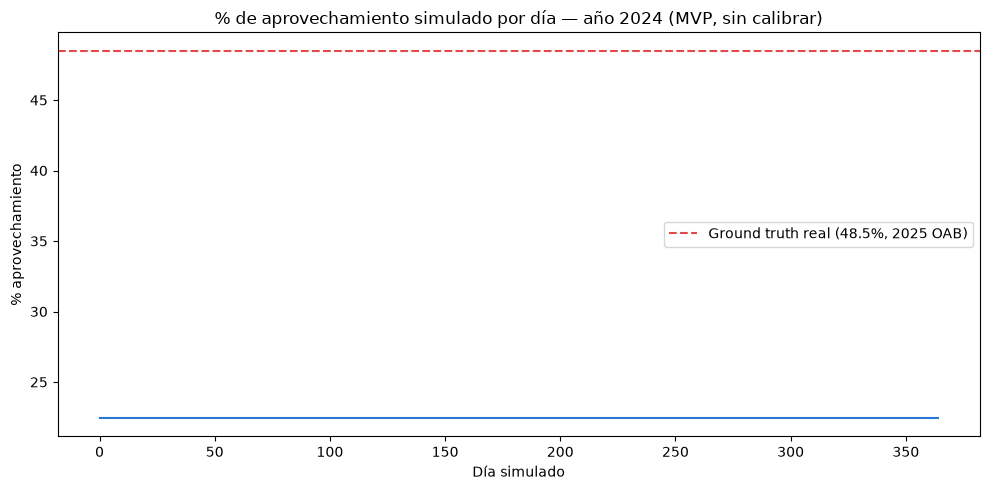

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(resultados_diarios.index, resultados_diarios["pct_aprovechamiento_dia"],
        color=eda.PALETA_CATEGORICA[0], linewidth=1.5)
ax.axhline(config_datos.APROVECHAMIENTO_GROUND_TRUTH_PCT, color=eda.PALETA_CATEGORICA[5],
           linestyle="--", label=f"Ground truth real ({config_datos.APROVECHAMIENTO_GROUND_TRUTH_PCT}%, 2025 OAB)")
ax.set_title("% de aprovechamiento simulado por día — año 2024 (MVP, sin calibrar)")
ax.set_xlabel("Día simulado")
ax.set_ylabel("% aprovechamiento")
ax.legend()
plt.tight_layout()
plt.show()


## 4. Resultado agregado vs. ground truth

El modelo no está calibrado todavía (ver `Diseno_ABM.md` §6 para el plan de calibración
post-MVP) — el objetivo de esta sección es solo confirmar que el orden de magnitud es
razonable, no que coincida con el 48.5% real.

In [5]:
pct_final = resultados_diarios["pct_aprovechamiento_dia"].tail(30).mean()
diferencia = pct_final - config_datos.APROVECHAMIENTO_GROUND_TRUTH_PCT

print(f"% de aprovechamiento simulado (promedio últimos 30 días): {pct_final:.2f}%")
print(f"% de aprovechamiento real (ground truth, 2025 OAB): {config_datos.APROVECHAMIENTO_GROUND_TRUTH_PCT:.2f}%")
print(f"Diferencia: {diferencia:+.2f} puntos porcentuales")
print()
print("Nota: el modelo arranca con parámetros supuestos (capacidad de reciclador, tasas de")
print("decaimiento/recuperación de la actitud de separación) sin calibrar contra el dato real.")
print("Un orden de magnitud razonable (mismo dígito, no 100x de diferencia) es el criterio de")
print("éxito de este MVP -- la calibración fina es la siguiente iteración.")


% de aprovechamiento simulado (promedio últimos 30 días): 22.44%
% de aprovechamiento real (ground truth, 2025 OAB): 48.50%
Diferencia: -26.06 puntos porcentuales

Nota: el modelo arranca con parámetros supuestos (capacidad de reciclador, tasas de
decaimiento/recuperación de la actitud de separación) sin calibrar contra el dato real.
Un orden de magnitud razonable (mismo dígito, no 100x de diferencia) es el criterio de
éxito de este MVP -- la calibración fina es la siguiente iteración.


## 5. Resultado por UPZ (descriptivo, no validado cuantitativamente)

**Importante:** no existe ningún dato real de aprovechamiento a nivel UPZ contra el cual
validar esta tabla — solo hay ground truth agregado a nivel ciudad. Esta sección se lee de
forma **descriptiva/direccional** ("¿el modelo produce menor aprovechamiento en UPZ de estrato
bajo, consistente con la dirección de la hipótesis?"), nunca como un resultado validado por UPZ
(ver `Diseno_ABM.md` §6 y §8).

In [6]:
resumen_upz = modelo.resumen_por_upz().sort_values("pct_aprovechamiento")
resumen_upz.head(10)


,UPZ,nombre_localidad,clasificacion_social,infraestructura_index,generado_acumulado_ton,aprovechado_acumulado_ton,rechazo_acumulado_ton,pct_aprovechamiento
90,96,Santa Fe,Baja,0.305050,12075.164706,0.000000,12075.164706,0.000000
87,93,Santa Fe,Media,0.868793,3671.084211,0.000000,3671.084211,0.000000
85,91,Santa Fe,Media,0.930413,2363.088000,0.000000,2363.088000,0.000000
86,92,Santa Fe,Baja,0.572160,2961.665299,0.000000,2961.665299,0.000000
89,95,Santa Fe,Baja,0.323654,5335.586667,0.000000,5335.586667,0.000000
75,81,Kennedy,Baja,0.200000,15892.631854,905.796484,14986.835370,5.699474
76,82,Kennedy,Baja,0.200000,34738.990380,1979.939864,32759.050516,5.699474
73,79,Kennedy,Baja,0.206717,32853.556129,1935.371651,30918.184478,5.890905
74,80,Kennedy,Baja,0.253291,14505.582609,1047.030624,13458.551985,7.218122
60,66,Ciudad Bolívar,Baja,0.200000,18840.144527,1538.483188,17301.661339,8.165984


In [7]:
resumen_upz.sort_values('pct_aprovechamiento', ascending=False).head(10)


,UPZ,nombre_localidad,clasificacion_social,infraestructura_index,generado_acumulado_ton,aprovechado_acumulado_ton,rechazo_acumulado_ton,pct_aprovechamiento
96,102,Los Mártires,Media,0.842074,9195.361649,7743.176561,1452.185089,84.207417
31,37,Los Mártires,Media,0.753883,11201.482303,8444.606444,2756.875859,75.388294
98,104,Teusaquillo,Alta,0.992956,562.434783,398.163301,164.271481,70.792795
95,101,Teusaquillo,Alta,0.861962,7187.998389,4417.284754,2770.713636,61.453614
103,109,Teusaquillo,Baja,0.835223,3651.403288,2174.311485,1477.091803,59.547284
94,100,Teusaquillo,Alta,0.825678,9973.769231,5871.231559,4102.537671,58.866728
101,107,Teusaquillo,Alta,0.822700,7314.497806,4290.274842,3024.222965,58.654401
2,3,Suba,Baja,0.995312,367.584000,210.336897,157.247103,57.221451
1,2,Suba,Baja,0.982176,385.143256,217.475895,167.667361,56.466235
100,106,Teusaquillo,Alta,0.779920,10188.607362,5665.314729,4523.292633,55.604407


> **Nota de calidad de datos (heredada de la Fase 1):** las localidades con muestra de
> encuesta muy pequeña (Los Mártires n=1, Santa Fe n=3 en `05_actores.csv`) alimentan un
> `pct_calidad_separacion`/`pct_separa_en_fuente` poco confiable, que se propaga directamente a
> estos resultados extremos (0% o >80%) — no son necesariamente errores del ABM, sino el reflejo
> de un dato de entrada débil. Ver `Revision_Comite_Tesis.md` para el hallazgo original.

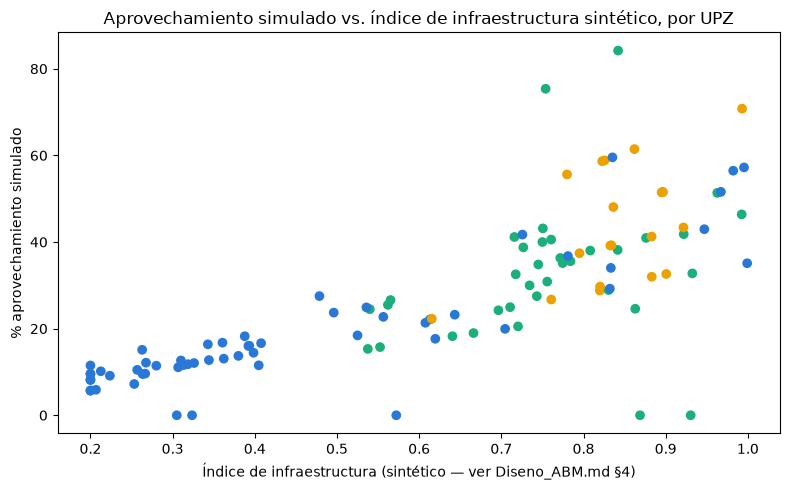

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(resumen_upz["infraestructura_index"], resumen_upz["pct_aprovechamiento"],
           c=[eda.PALETA_CATEGORICA[0] if c == "Baja" else eda.PALETA_CATEGORICA[1] if c == "Media"
              else eda.PALETA_CATEGORICA[2] for c in resumen_upz["clasificacion_social"]])
ax.set_xlabel("Índice de infraestructura (sintético — ver Diseno_ABM.md §4)")
ax.set_ylabel("% aprovechamiento simulado")
ax.set_title("Aprovechamiento simulado vs. índice de infraestructura sintético, por UPZ")
plt.tight_layout()
plt.show()


### 5.1 Mapa real de Bogotá

El scatter anterior ya mostraba la relación entre infraestructura e índice de aprovechamiento,
pero sin ubicación geográfica. Aquí se une el resumen por UPZ con los polígonos reales de
`IndUPZ.gpkg` (mismo patrón de `src/eda.py` usado en la Fase 1) para ver el resultado sobre el
mapa real de la ciudad — no se usa `mesa-geo`, solo un join de la salida agregada con la
geometría, ya que el modelo nunca necesitó que sus agentes vivieran en un espacio geográfico.

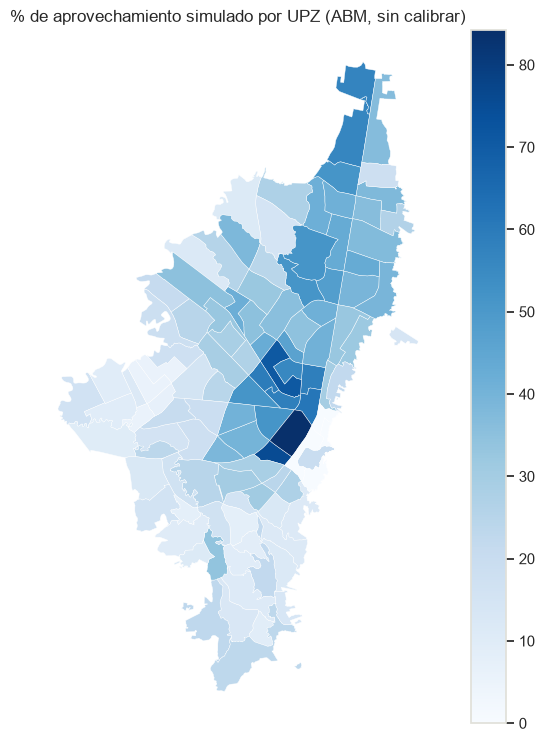

In [9]:
from abm import visualizacion_mapa

fig_mapa = visualizacion_mapa.graficar_mapa_aprovechamiento(resumen_upz)
plt.show()


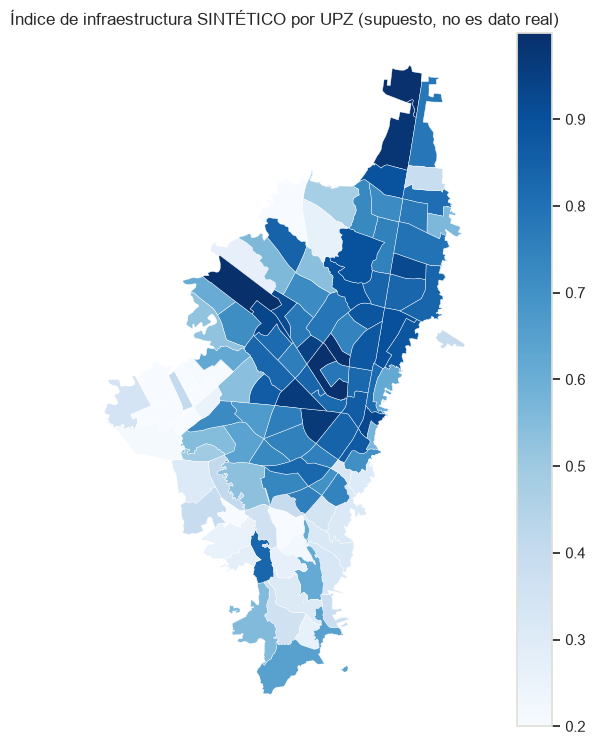

In [10]:
fig_mapa_infra = visualizacion_mapa.graficar_mapa_infraestructura(resumen_upz)
plt.show()


## 6. Próximos pasos (post-MVP)

Este notebook confirma que el modelo corre de extremo a extremo y produce un resultado del
orden de magnitud esperado. Lo que sigue, según `Diseno_ABM.md` §6-7, **no implementado aquí
todavía**:

1. **Calibración** (`abm/calibracion.py`, no creado aún): ajustar `capacidad_recoleccion_individual`,
   las tasas de decaimiento/recuperación, y los coeficientes del índice de infraestructura para
   acercar el % agregado al 48.5% real, reportando un rango de parámetros plausibles (no un
   único "mejor ajuste" — hay ~4-6 parámetros libres contra un solo número real).
2. **Validaciones formales** (`abm/validaciones_abm.py`): balance de masa contra `residuos_pidj`
   y `rechazo_punto_limpio`, barridos de sensibilidad uno-a-la-vez, réplica histórica 2018-2023.
3. **Escenarios** (`abm/escenarios.py`, y llenar `07_escenarios.csv`): comparar la línea base
   calibrada contra escenarios de inversión en infraestructura o mejora de coordinación
   reciclador-sistema formal, con múltiples réplicas (≥30 semillas) reportadas como media ± dispersión.
